In [1]:
from topological_insulator import Problem

In [2]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "honeycomb.json"

In [3]:
import numpy as np

def set_eigenvalues(problem:Problem, Delta_SOC, t_1, delta):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    for label_i in subs:
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        parser["chadi_soc"][label_i]["Delta_pp"] = Delta_SOC
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings
            try:
                # parser["nn_hopping"][label_j]["t_ss_sigma"] = 0.2 * t_1
                # parser["nn_hopping"][label_j]["t_sp_sigma"] = 1
                parser["nn_hopping"][label_j]["t_pp_sigma"] = t_1 - delta
                parser["nn_hopping"][label_j]["t_pp_pi"] = t_1 + delta
            except:
                pass
        # print(parser)   

In [4]:
location = "bulk"

In [5]:
Delta_SOC = -5
cases = {
    0: {"t_1": -1, "delta": 0.632},
    1: {"t_1": -1, "delta": 0.832}
}

In [6]:
results = {}
for n, eigenvalue_dict in cases.items():
    t_1 = eigenvalue_dict["t_1"]
    delta = eigenvalue_dict["delta"]
    print("")
    print(f"Running case for: delta/t_1 = {delta/t_1}")
    problem = Problem(structure_path=structure_path, structure_name=structure_name)
    set_eigenvalues(problem, Delta_SOC, t_1, delta)
    problem.setup(
        N_r = 10,
        N_k = 200,
        location = location,
        BZ = "reduced"
    )
    problem.run(
        H_type="reciprocal"
    )
    results[n] = problem


Running case for: delta/t_1 = -0.632
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!

Running case for: delta/t_1 = -0.832
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


In [7]:
j_3_2 = [8, 9, 10, 11, 12, 13, 14, 15]
bands = [12, 13, 14, 15]

## Case 0

In [8]:
g = results[0].geometry
tb_bulk = results[0].hamiltonian[location]["tight_binding"]
invariants = results[0].hamiltonian[location]["topological_invariants"]

Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = -1.0
k=[1.04719755 1.81379936]: delta = -1.0
k=[ 1.04719755 -1.81379936]: delta = 1.0
k=[2.0943951 0.       ]: delta = 1.0
Z2 Invariant - Done!
Z2 Invariant: 0


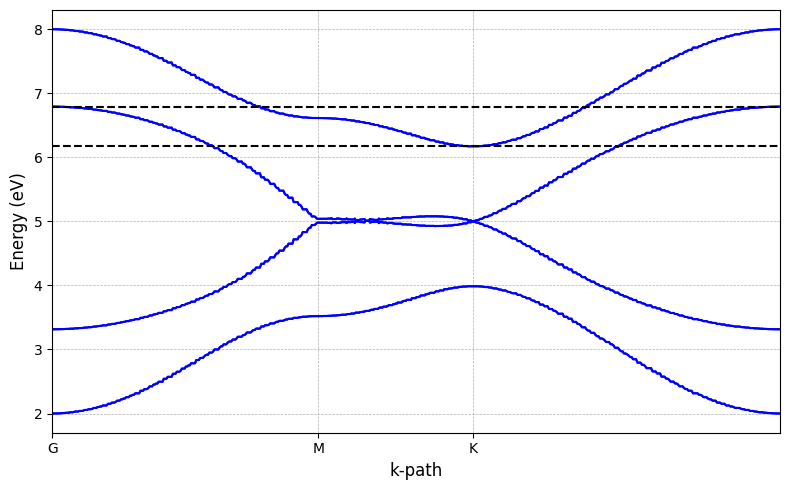

In [9]:
Z2 = invariants.Z2_invariant(bands, print_deltas=True)
print(f"Z2 Invariant: {Z2}")
dE, E_0, E_1 = invariants.get_band_gap(15, 13, only_dE=False)
tb_bulk.plot_band_structure(g, j_3_2, energies=[E_0, E_1])

In [10]:
N_projections = len(tb_bulk.coupled_states)
N_sites = len(tb_bulk.sublattice_idxs)
N_bands = N_sites * N_projections
key = "[-3.141592653589793, -3.141592653589793]"
U_k = tb_bulk.U_k_dict[key]
c_m = U_k[:, 0]

c_m

array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        2.57190489e-02-0.00000000e+00j,  7.02072391e-01-1.04568773e-01j,
        6.61453882e-03+1.65567733e-02j,  1.06050557e-03-3.94239546e-07j,
       -2.94723837e-02+4.40042798e-03j,  7.61426431e-04-1.29212241e-03j,
        1.11022302e-16-2.08166817e-17j, -1.66533454e-16-2.09928646e-17j,
       -1.25039126e-02-2.28533697e-02j, -4.23268996e-01-5.58522255e-01j,
       -1.55289926e-02+3.78003465e-02j, -5.24589662e-04-9.59602114e-04j,
        1.74446161e-02+2.30367318e-02j,  6.30902959e-04-1.73532950e-04j])

## Case 1

In [11]:
g = results[1].geometry
tb_bulk = results[1].hamiltonian[location]["tight_binding"]
invariants = results[1].hamiltonian[location]["topological_invariants"]

Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = -1.0
k=[1.04719755 1.81379936]: delta = -1.0
k=[ 1.04719755 -1.81379936]: delta = -1.0
k=[2.0943951 0.       ]: delta = 1.0
Z2 Invariant - Done!
Z2 Invariant: 1


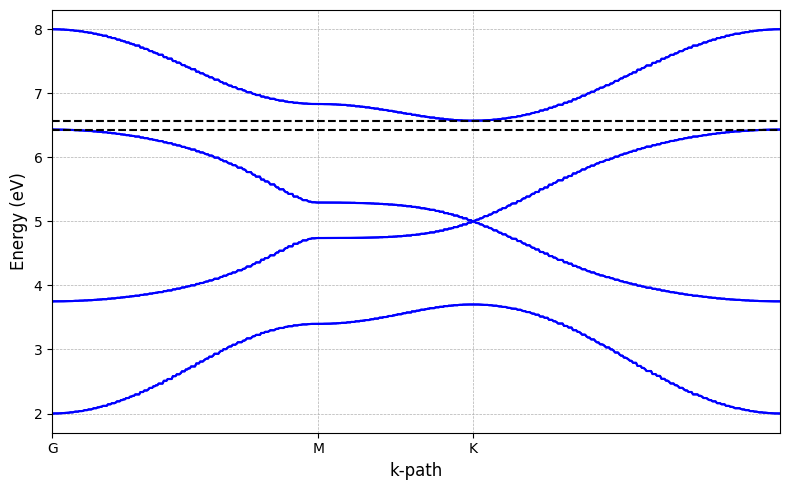

In [13]:
Z2 = invariants.Z2_invariant(bands, print_deltas=True)
print(f"Z2 Invariant: {Z2}")
dE, E_0, E_1 = invariants.get_band_gap(15, 13, only_dE=False)
tb_bulk.plot_band_structure(g, j_3_2, energies=[E_0, E_1])
